# [[8,2,3]] Code Data Generation - Self-Contained

Fully self-contained implementation for syndrome data generation.
No local imports required - only reads the network graph pickle file.

**Code Parameters:**
- Physical qubits: 8
- Logical qubits: 2
- Distance: 3
- Stabilizers: 6

**Protocol:**
1. Encode two logical qubits at source using [[8,2,3]] code
2. SWAP encoded state along multi-hop path to sink
3. Measure syndrome at sink

No corrections applied - just raw syndrome observation.

In [1]:
# =============================================================================
# IMPORTS (External packages only)
# =============================================================================
from qiskit import QuantumCircuit, transpile, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel
from qiskit_ibm_runtime.fake_provider import FakeFez
from qiskit.visualization import plot_histogram

import numpy as np
import networkx as nx
import pickle
import os
from typing import Dict, List, Tuple
from itertools import combinations

## Qubit Mapping Constants

Physical qubit mapping for 8-node fully connected network with [[8,2,3]] code.

- **Node qubits**: 14 per node (8 data + 6 ancilla) = 112 qubits
- **Path qubits**: 1 per edge = 28 qubits (C(8,2) edges)
- **Total**: 140 qubits

In [2]:
# =============================================================================
# QUBIT MAPPING CONSTANTS
# =============================================================================

# Node qubits: 14 per node (8 data + 6 ancilla)
NODE_PHYSICAL_QUBITS_823: Dict[int, List[int]] = {
    0: list(range(0, 14)),      # Node 0 → physical qubits 0-13
    1: list(range(14, 28)),     # Node 1 → physical qubits 14-27
    2: list(range(28, 42)),     # Node 2 → physical qubits 28-41
    3: list(range(42, 56)),     # Node 3 → physical qubits 42-55
    4: list(range(56, 70)),     # Node 4 → physical qubits 56-69
    5: list(range(70, 84)),     # Node 5 → physical qubits 70-83
    6: list(range(84, 98)),     # Node 6 → physical qubits 84-97
    7: list(range(98, 112)),    # Node 7 → physical qubits 98-111
}

# Path qubits: 1 per edge for SWAP transport
# All 28 edges of a fully connected 8-node graph
PATH_PHYSICAL_QUBITS_823: Dict[Tuple[int, int], List[int]] = {
    # Node 0 edges
    (0, 1): [112], (0, 2): [113], (0, 3): [114], (0, 4): [115],
    (0, 5): [116], (0, 6): [117], (0, 7): [118],
    # Node 1 edges
    (1, 2): [119], (1, 3): [120], (1, 4): [121],
    (1, 5): [122], (1, 6): [123], (1, 7): [124],
    # Node 2 edges
    (2, 3): [125], (2, 4): [126], (2, 5): [127], (2, 6): [128], (2, 7): [129],
    # Node 3 edges
    (3, 4): [130], (3, 5): [131], (3, 6): [132], (3, 7): [133],
    # Node 4 edges
    (4, 5): [134], (4, 6): [135], (4, 7): [136],
    # Node 5 edges
    (5, 6): [137], (5, 7): [138],
    # Node 6 edges
    (6, 7): [139],
}

# Total qubits: 112 (nodes) + 28 (paths) = 140
TOTAL_QUBITS_823: int = 140

# [[8,2,3]] Stabilizer generators (Qiskit little-endian convention)
# String index 0 = qubit 7, string index 7 = qubit 0
STABILIZERS_823 = [
    "XIIIYZZZ",
    "ZIIXIYII",
    "IXIZYXIX",
    "IZIYZXXY",
    "IIXYXZYZ",
    "IIZIIIYX",
]

# Number of syndrome bits
NUM_SYNDROMES_823 = 6

# Basis gates for transpilation
BASIS_GATES = ['cx', 'cz', 'id', 'rz', 'sx', 'x', 'reset']

print(f"[[8,2,3]] Code Configuration:")
print(f"  Data qubits per node: 8")
print(f"  Ancilla qubits per node: 6")
print(f"  Total qubits: {TOTAL_QUBITS_823}")
print(f"  Stabilizers: {len(STABILIZERS_823)}")

[[8,2,3]] Code Configuration:
  Data qubits per node: 8
  Ancilla qubits per node: 6
  Total qubits: 140
  Stabilizers: 6


## Helper Functions

In [3]:
# =============================================================================
# HELPER FUNCTIONS
# =============================================================================

def get_edge_key(node_a: int, node_b: int) -> Tuple[int, int]:
    """Get canonical edge key (smaller node first)."""
    return (min(node_a, node_b), max(node_a, node_b))


def get_node_qubits_823(node_id: int) -> Dict[str, List[int]]:
    """
    Get qubit indices for a node with named access.

    Returns:
        Dictionary with keys 'data' (8 qubits) and 'ancilla' (6 qubits)
    """
    if node_id not in NODE_PHYSICAL_QUBITS_823:
        raise ValueError(f"Invalid node_id: {node_id}. Valid: 0-{len(NODE_PHYSICAL_QUBITS_823)-1}")

    qubits = NODE_PHYSICAL_QUBITS_823[node_id]
    return {
        'data': qubits[0:8],
        'ancilla': qubits[8:14],
    }


def get_path_qubits_823(node_a: int, node_b: int) -> List[int]:
    """Get path qubit(s) for an edge (SWAP-based transport)."""
    edge_key = get_edge_key(node_a, node_b)
    if edge_key not in PATH_PHYSICAL_QUBITS_823:
        raise ValueError(f"No path defined for edge {edge_key}")
    return PATH_PHYSICAL_QUBITS_823[edge_key]


def print_qubit_mapping_823() -> None:
    """Print the qubit mapping for SWAP-based transport."""
    print("=" * 60)
    print("[[8,2,3]] Code Physical Qubit Mapping (SWAP-based)")
    print("=" * 60)

    print("\nNode Qubits (14 per node: 8 data + 6 ancilla):")
    print("-" * 40)
    for node, qubits in NODE_PHYSICAL_QUBITS_823.items():
        print(f"  Node {node}: qubits {qubits[0]:3d}-{qubits[-1]:3d} "
              f"(data={qubits[0]}-{qubits[7]}, ancilla={qubits[8]}-{qubits[13]})")

    print("\nPath Qubits (1 per edge):")
    print("-" * 40)
    for edge, qubits in list(PATH_PHYSICAL_QUBITS_823.items())[:7]:
        print(f"  Edge {edge}: qubit(s) {qubits}")
    print(f"  ... and {len(PATH_PHYSICAL_QUBITS_823) - 7} more edges")

    print(f"\nTotal qubits: {TOTAL_QUBITS_823}")
    print("=" * 60)

## [[8,2,3]] Code Functions

In [4]:
# =============================================================================
# [[8,2,3]] CODE FUNCTIONS
# =============================================================================

def encoding_823_static() -> QuantumCircuit:
    """
    Pre-computed encoding circuit for [[8,2,3]] code.
    
    This circuit prepares |00⟩_L from |00000000⟩.
    Derived from StabilizerState using the 6 stabilizers and 2 logical Z operators.
    """
    qc = QuantumCircuit(8)
    qc.s(4)
    qc.h(4)
    qc.cx(5, 7)
    qc.cx(2, 5)
    qc.cx(3, 5)
    qc.cx(4, 5)
    qc.cx(6, 5)
    qc.h(2)
    qc.s(7)
    qc.h(7)
    qc.s(7)
    qc.s(6)
    qc.h(6)
    qc.s(6)
    qc.cx(0, 6)
    qc.cx(2, 6)
    qc.cx(7, 3)
    qc.cx(3, 6)
    qc.cx(6, 7)
    qc.s(3)
    qc.h(3)
    qc.s(3)
    qc.h(4)
    qc.s(4)
    qc.cx(7, 0)
    qc.cx(3, 4)
    qc.cx(4, 0)
    qc.cx(0, 3)
    qc.h(7)
    qc.h(2)
    qc.swap(7, 1)
    qc.cx(4, 7)
    qc.cx(2, 7)
    qc.cx(1, 7)
    qc.h(4)
    qc.s(2)
    qc.s(3)
    qc.swap(4, 1)
    qc.cx(4, 2)
    qc.cx(4, 3)
    qc.cx(1, 4)
    qc.s(1)
    qc.h(1)
    qc.swap(2, 1)
    qc.cx(1, 2)
    qc.s(3)
    qc.h(1)
    qc.s(1)
    qc.swap(3, 1)
    qc.cx(3, 1)
    qc.z(0)
    qc.z(1)
    qc.x(3)
    qc.x(4)
    qc.x(5)
    qc.x(7)
    return qc


# Pre-compute the encoding circuit
_ENCODING_CIRCUIT_823 = encoding_823_static()
print(f"[[8,2,3]] encoding circuit: {_ENCODING_CIRCUIT_823.count_ops()}")


def apply_encoding_823(qc: QuantumCircuit, qubits: List[int]) -> None:
    """
    Apply [[8,2,3]] encoding circuit to specified qubits.

    NOTE: This encoding prepares |00⟩_L. To encode |ψ₁ψ₂⟩, apply X gates
    to qubits[0] and qubits[1] BEFORE calling this function.

    Args:
        qc: QuantumCircuit to add gates to
        qubits: List of 8 qubit indices [q0, q1, q2, q3, q4, q5, q6, q7]
    """
    if len(qubits) != 8:
        raise ValueError(f"Expected 8 qubits, got {len(qubits)}")

    for instruction in _ENCODING_CIRCUIT_823.data:
        gate = instruction.operation
        gate_qubits = [qubits[_ENCODING_CIRCUIT_823.find_bit(q).index] for q in instruction.qubits]
        qc.append(gate, gate_qubits)


def apply_syndrome_measurement_823(
    qc: QuantumCircuit,
    data_qubits: List[int],
    ancilla_qubits: List[int],
    classical_bits,
    reset_ancillas: bool = True
) -> None:
    """
    Extract syndrome and measure ancilla qubits for [[8,2,3]] code.
    
    Uses the CORRECT approach:
    - Ancilla is CONTROL, data is TARGET
    - Little-endian indexing (string index i → qubit n-1-i)
    - Native CY gate for controlled-Y

    Args:
        qc: QuantumCircuit to add gates to
        data_qubits: List of 8 data qubit indices [q0, q1, ..., q7]
        ancilla_qubits: List of 6 ancilla qubit indices [a0, a1, ..., a5]
        classical_bits: ClassicalRegister or list of 6 classical bit indices
        reset_ancillas: If True, reset ancillas to |0⟩ before extraction
    """
    if len(data_qubits) != 8:
        raise ValueError(f"Expected 8 data qubits, got {len(data_qubits)}")
    if len(ancilla_qubits) != 6:
        raise ValueError(f"Expected 6 ancilla qubits, got {len(ancilla_qubits)}")

    if reset_ancillas:
        for ancilla in ancilla_qubits:
            qc.reset(ancilla)

    n = 8  # Number of data qubits
    for idx, stabilizer in enumerate(STABILIZERS_823):
        ancilla = ancilla_qubits[idx]
        qc.h(ancilla)
        
        # CRITICAL: Little-endian indexing
        # String position i corresponds to qubit index (n-1-i)
        for str_idx, pauli in enumerate(stabilizer):
            qubit_idx = n - 1 - str_idx
            if pauli == 'X':
                qc.cx(ancilla, data_qubits[qubit_idx])
            elif pauli == 'Z':
                qc.cz(ancilla, data_qubits[qubit_idx])
            elif pauli == 'Y':
                qc.cy(ancilla, data_qubits[qubit_idx])
        
        qc.h(ancilla)
        qc.measure(ancilla, classical_bits[idx])


def apply_swap_along_edge(qc: QuantumCircuit, source_qubits: List[int], 
                          sink_qubits: List[int], path_qubits: List[int]) -> None:
    """SWAP all 8 code qubits from source to sink via path qubits."""
    num_path_qubits = len(path_qubits)
    for i in range(8):  # 8 data qubits for [[8,2,3]] code
        qc.swap(source_qubits[i], path_qubits[0])
        for j in range(num_path_qubits - 1):
            qc.swap(path_qubits[j], path_qubits[j + 1])
        qc.swap(path_qubits[num_path_qubits - 1], sink_qubits[i])

[[8,2,3]] encoding circuit: OrderedDict({'cx': 22, 's': 13, 'h': 11, 'swap': 4, 'x': 4, 'z': 2})


## Data Container Class

In [5]:
# =============================================================================
# DATA CONTAINER CLASS
# =============================================================================

class TimeAwareMeasurement:
    def __init__(self, path_edges, histogram, duration, latency_stats=None, code_type='823'):
        """
        Container for syndrome measurement results.
        
        :param path_edges: List of tuples representing the path, e.g., [(0,1), (1,2)]
        :param histogram: A 64-dimensional numpy array of syndrome counts (2^6 syndromes).
        :param duration: The duration or average latency of this measurement (seconds).
        :param latency_stats: A dictionary with 'max', 'std', 'count'.
        :param code_type: String indicating the code type, e.g., '823'.
        """
        self.path_edges = path_edges
        self.histogram = histogram
        self.duration = duration
        self.latency_stats = latency_stats
        self.code_type = code_type

## Configuration

In [6]:
# =============================================================================
# CONFIGURATION
# =============================================================================

# Experiment parameters
MAX_HOPS = 3
MIN_HOPS = 2
NUM_SHOTS = 4096
OPTIMIZATION_LEVEL = 1

# Paths - UPDATE THESE FOR YOUR SETUP
NETWORK_GRAPH_PATH = '../networkgraphs/2x3_grid_network_graph.pkl'
OUTPUT_DIR = '../pickle_files/syndrome_data_823'

In [7]:
# Display qubit mapping
print_qubit_mapping_823()

[[8,2,3]] Code Physical Qubit Mapping (SWAP-based)

Node Qubits (14 per node: 8 data + 6 ancilla):
----------------------------------------
  Node 0: qubits   0- 13 (data=0-7, ancilla=8-13)
  Node 1: qubits  14- 27 (data=14-21, ancilla=22-27)
  Node 2: qubits  28- 41 (data=28-35, ancilla=36-41)
  Node 3: qubits  42- 55 (data=42-49, ancilla=50-55)
  Node 4: qubits  56- 69 (data=56-63, ancilla=64-69)
  Node 5: qubits  70- 83 (data=70-77, ancilla=78-83)
  Node 6: qubits  84- 97 (data=84-91, ancilla=92-97)
  Node 7: qubits  98-111 (data=98-105, ancilla=106-111)

Path Qubits (1 per edge):
----------------------------------------
  Edge (0, 1): qubit(s) [112]
  Edge (0, 2): qubit(s) [113]
  Edge (0, 3): qubit(s) [114]
  Edge (0, 4): qubit(s) [115]
  Edge (0, 5): qubit(s) [116]
  Edge (0, 6): qubit(s) [117]
  Edge (0, 7): qubit(s) [118]
  ... and 21 more edges

Total qubits: 140


## Noise Model

In [8]:
# =============================================================================
# NOISE MODEL
# =============================================================================
# Custom noise model:
# 1. Copy 1Q errors from FakeFez (per-qubit depolarizing, realistic rates)
# 2. Add custom 2Q depolarizing errors for all qubit pairs (all-to-all connectivity)

from qiskit_aer.noise import depolarizing_error

fake_backend = FakeFez()
target = fake_backend.target

noise_model = NoiseModel()

# --- 1. Copy 1Q errors from FakeFez ---
gates_to_copy = ['sx', 'x', 'rz', 'id']
copied_1q_count = 0

for gate in gates_to_copy:
    if gate not in target.operation_names:
        continue
    for qargs in target.qargs_for_operation_name(gate):
        props = target[gate][qargs]
        if props and props.error and props.error > 0:
            error = depolarizing_error(props.error, 1)
            noise_model.add_quantum_error(error, gate, list(qargs))
            copied_1q_count += 1

# --- 2. Add custom 2Q depolarizing errors for all qubit pairs ---
ERROR_RATE_2Q = 0.01  # 1% error for two-qubit gates
error_2q = depolarizing_error(ERROR_RATE_2Q, 2)

for i in range(TOTAL_QUBITS_823):
    for j in range(i + 1, TOTAL_QUBITS_823):
        noise_model.add_quantum_error(error_2q, 'cx', [i, j])
        noise_model.add_quantum_error(error_2q, 'cx', [j, i])
        noise_model.add_quantum_error(error_2q, 'cz', [i, j])
        noise_model.add_quantum_error(error_2q, 'cz', [j, i])

print(f"Backend reference: {fake_backend.name} ({fake_backend.num_qubits} qubits)")
print(f"1Q errors copied: {copied_1q_count} entries (from FakeFez)")
print(f"2Q error rate: {ERROR_RATE_2Q} (custom, all-to-all)")
print(f"Circuit qubits: {TOTAL_QUBITS_823}")
print(f"Transpilation basis gates: {BASIS_GATES}")

Backend: fake_fez (156 qubits)
Noise model basis gates: ['cz', 'delay', 'for_loop', 'id', 'if_else', 'measure', 'reset', 'rz', 'switch_case', 'sx', 'x']
Transpilation basis gates: ['cx', 'cz', 'id', 'rz', 'sx', 'x', 'reset']


## Load Network

Network nodes: [0, 1, 2, 3, 4, 5]
Network edges: [(0, 1), (0, 3), (1, 2), (1, 4), (2, 5), (3, 4), (4, 5)]


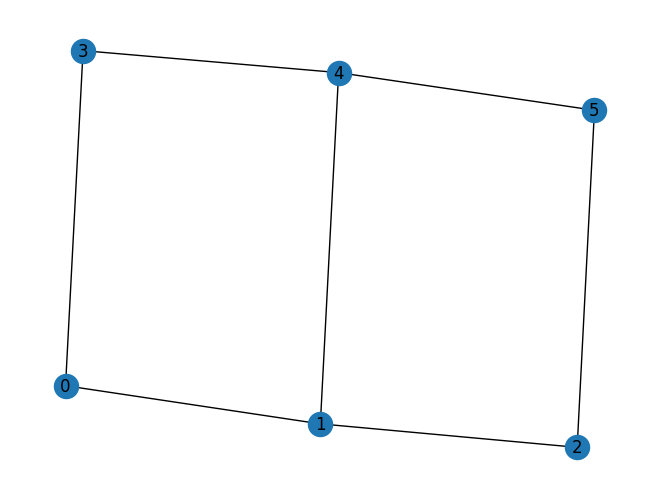

In [9]:
# =============================================================================
# LOAD NETWORK GRAPH
# =============================================================================

with open(NETWORK_GRAPH_PATH, 'rb') as f:
    network_graph = pickle.load(f)

print(f"Network nodes: {list(network_graph.nodes())}")
print(f"Network edges: {list(network_graph.edges())}")
nx.draw(network_graph, with_labels=True)

In [10]:
# =============================================================================
# GENERATE ALL MULTI-HOP PATHS
# =============================================================================

ALL_PATHS = []
for pair in combinations(network_graph.nodes, 2):
    paths = nx.all_simple_paths(network_graph, source=pair[0], target=pair[1], cutoff=MAX_HOPS)
    ALL_PATHS.extend([p for p in paths if len(p) > MIN_HOPS])

print(f"Total paths ({MIN_HOPS}-{MAX_HOPS} hops): {len(ALL_PATHS)}")
print(f"Sample: {ALL_PATHS[:5] if ALL_PATHS else 'None'}")

Total paths (2-3 hops): 24
Sample: [[0, 3, 4, 1], [0, 1, 2], [0, 1, 4, 3], [0, 1, 4], [0, 3, 4]]


## Circuit Builder

In [11]:
# =============================================================================
# CIRCUIT BUILDER
# =============================================================================

def build_823_swap_circuit(path: list, initial_state: str = '00') -> QuantumCircuit:
    """
    Build a [[8,2,3]] encode-swap-syndrome circuit.
    
    Protocol:
        1. Encode two logical qubits at source
        2. SWAP along path to sink
        3. Measure syndrome at sink
    
    Args:
        path: List of node IDs, e.g., [0, 1, 2]
        initial_state: '00', '01', '10', or '11' (two logical qubits)
    
    Returns:
        QuantumCircuit with syndrome measurement
    """
    source = path[0]
    sink = path[-1]
    
    # Get qubit assignments
    source_qubits = get_node_qubits_823(source)
    sink_qubits = get_node_qubits_823(sink)
    
    # Create circuit
    qc = QuantumCircuit(TOTAL_QUBITS_823)
    syndrome_reg = ClassicalRegister(6, name=f'syndrome_{sink}')
    qc.add_register(syndrome_reg)
    
    # ===================
    # 1. ENCODE AT SOURCE
    # ===================
    if len(initial_state) != 2:
        raise ValueError(f"initial_state must be 2 bits, got '{initial_state}'")
    
    # Set logical qubit values before encoding
    if initial_state[0] == '1':
        qc.x(source_qubits['data'][0])
    if initial_state[1] == '1':
        qc.x(source_qubits['data'][1])
    
    apply_encoding_823(qc, source_qubits['data'])
    qc.barrier(label='Encode')
    
    # ===================
    # 2. SWAP ALONG PATH
    # ===================
    for i in range(len(path) - 1):
        src_node = path[i]
        dst_node = path[i + 1]
        
        src_data = get_node_qubits_823(src_node)['data']
        dst_data = get_node_qubits_823(dst_node)['data']
        path_qubits = get_path_qubits_823(src_node, dst_node)
        
        apply_swap_along_edge(qc, src_data, dst_data, path_qubits)
    
    qc.barrier(label='Swap')
    
    # ===================
    # 3. SYNDROME AT SINK
    # ===================
    apply_syndrome_measurement_823(
        qc,
        sink_qubits['data'],
        sink_qubits['ancilla'],
        syndrome_reg
    )
    
    return qc

## Test Circuit

In [12]:
# =============================================================================
# TEST CIRCUIT
# =============================================================================

test_path = [0, 1, 2]
test_circuit = build_823_swap_circuit(test_path, initial_state='00')

print(f"Path: {test_path}")
print(f"Qubits: {test_circuit.num_qubits}")
print(f"Classical bits: {test_circuit.num_clbits}")
print(f"Gate counts: {test_circuit.count_ops()}")

Path: [0, 1, 2]
Qubits: 140
Classical bits: 6
Gate counts: OrderedDict({'swap': 36, 'cx': 32, 'h': 23, 's': 13, 'cz': 10, 'cy': 8, 'reset': 6, 'measure': 6, 'x': 4, 'z': 2, 'barrier': 2})


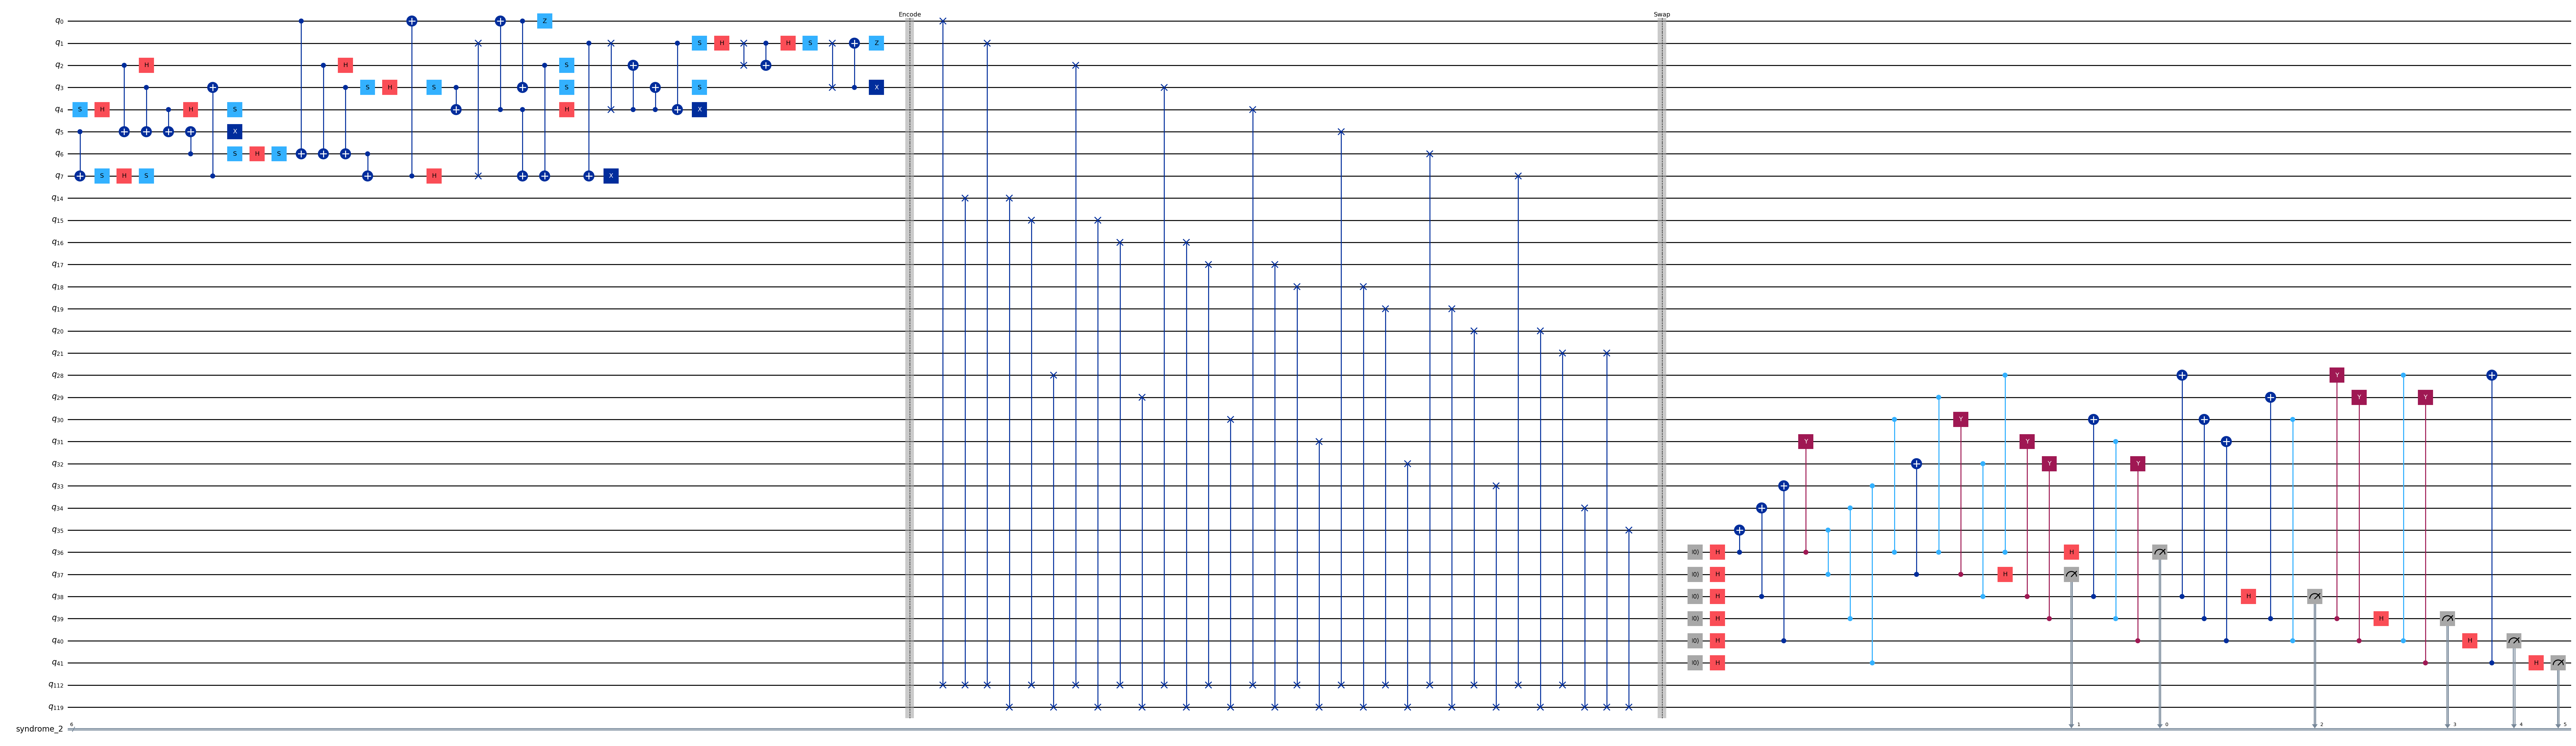

In [13]:
test_circuit.draw('mpl', fold=-1, idle_wires=False)

Noiseless syndrome counts (expect '000000'): {'000000': 4096}


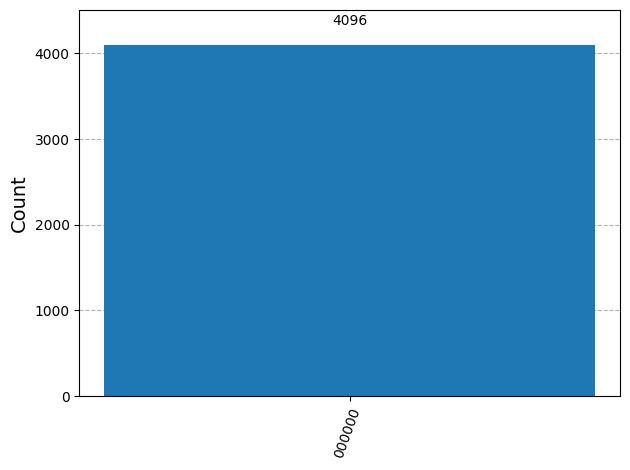

In [14]:
# =============================================================================
# NOISELESS SIMULATION
# =============================================================================

simulator = AerSimulator(method='matrix_product_state')
transpiled = transpile(test_circuit, basis_gates=BASIS_GATES, optimization_level=OPTIMIZATION_LEVEL)

result = simulator.run(transpiled, shots=NUM_SHOTS).result()
counts = result.get_counts()

print(f"Noiseless syndrome counts (expect '000000'): {counts}")
plot_histogram(counts)

Noisy syndrome counts:
{'000000': 4072, '000100': 5, '100000': 3, '000010': 3, '001000': 2, '000001': 2, '001101': 2, '110000': 2, '010000': 1, '101000': 1}


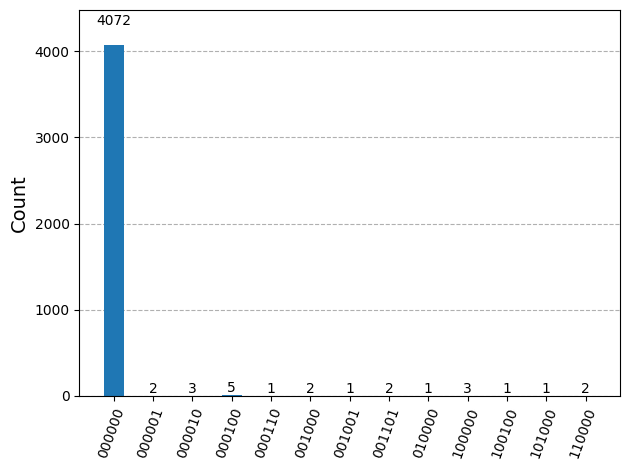

In [15]:
# =============================================================================
# NOISY SIMULATION
# =============================================================================

noisy_simulator = AerSimulator(noise_model=noise_model, method='matrix_product_state')

noisy_result = noisy_simulator.run(transpiled, shots=NUM_SHOTS).result()
noisy_counts = noisy_result.get_counts()

print("Noisy syndrome counts:")
print(dict(sorted(noisy_counts.items(), key=lambda x: -x[1])[:10]))
plot_histogram(noisy_counts)

## Data Generation

In [16]:
# =============================================================================
# DATA GENERATION
# =============================================================================

# Setup simulator
noisy_sim = AerSimulator(noise_model=noise_model, method='matrix_product_state')

measurements = []

print("=" * 60)
print("[[8,2,3]] SYNDROME DATA GENERATION")
print("=" * 60)
print(f"Paths to process: {len(ALL_PATHS)}")
print("=" * 60)

for idx, path in enumerate(ALL_PATHS):
    print(f"\n[{idx+1}/{len(ALL_PATHS)}] Path: {path}")
    
    # Build circuit
    circuit = build_823_swap_circuit(path, initial_state='00')
    transpiled = transpile(circuit, basis_gates=BASIS_GATES, optimization_level=OPTIMIZATION_LEVEL)
    
    # Run simulation
    result = noisy_sim.run(transpiled, shots=NUM_SHOTS).result()
    counts = result.get_counts()
    
    # Convert to histogram (64 bins for 6 syndrome bits)
    histogram = np.zeros(64, dtype=int)
    for syndrome_str, count in counts.items():
        syndrome_idx = int(syndrome_str, 2)
        histogram[syndrome_idx] = count
    
    # Extract path edges
    path_edges = [(path[i], path[i+1]) for i in range(len(path)-1)]
    
    # Store measurement
    measurement = TimeAwareMeasurement(
        path_edges=path_edges,
        histogram=histogram,
        duration=0.0,  # Placeholder
        code_type='823'
    )
    measurements.append(measurement)
    
    # Print summary
    no_error_frac = histogram[0] / histogram.sum()
    print(f"  Edges: {path_edges}")
    print(f"  No-error fraction: {no_error_frac:.4f}")

print("\n" + "=" * 60)
print(f"Data generation complete: {len(measurements)} measurements")
print("=" * 60)

[[8,2,3]] SYNDROME DATA GENERATION
Paths to process: 24

[1/24] Path: [0, 3, 4, 1]
  Edges: [(0, 3), (3, 4), (4, 1)]
  No-error fraction: 0.9973

[2/24] Path: [0, 1, 2]
  Edges: [(0, 1), (1, 2)]
  No-error fraction: 0.9954

[3/24] Path: [0, 1, 4, 3]
  Edges: [(0, 1), (1, 4), (4, 3)]
  No-error fraction: 0.9939

[4/24] Path: [0, 1, 4]
  Edges: [(0, 1), (1, 4)]
  No-error fraction: 0.9944

[5/24] Path: [0, 3, 4]
  Edges: [(0, 3), (3, 4)]
  No-error fraction: 0.9944

[6/24] Path: [0, 1, 2, 5]
  Edges: [(0, 1), (1, 2), (2, 5)]
  No-error fraction: 0.9897

[7/24] Path: [0, 1, 4, 5]
  Edges: [(0, 1), (1, 4), (4, 5)]
  No-error fraction: 0.9912

[8/24] Path: [0, 3, 4, 5]
  Edges: [(0, 3), (3, 4), (4, 5)]
  No-error fraction: 0.9880

[9/24] Path: [1, 4, 5, 2]
  Edges: [(1, 4), (4, 5), (5, 2)]
  No-error fraction: 0.9941

[10/24] Path: [1, 0, 3]
  Edges: [(1, 0), (0, 3)]
  No-error fraction: 0.9883

[11/24] Path: [1, 4, 3]
  Edges: [(1, 4), (4, 3)]
  No-error fraction: 0.9919

[12/24] Path: [1,

## Ground Truth

In [17]:
# =============================================================================
# GROUND TRUTH CIRCUIT (SWAP-based transport)
# =============================================================================

def build_ground_truth_circuit(source, sink, initial_state='0', measurement_basis='Z'):
    """
    Build a ground truth circuit for single-qubit transport using SWAP chains.
    
    This circuit transports a SINGLE (unencoded) qubit from source to sink
    and measures in the specified basis to determine error rates.
    """
    source_qubits = NODE_PHYSICAL_QUBITS_823[source]
    sink_qubits = NODE_PHYSICAL_QUBITS_823[sink]
    
    edge_key = (min(source, sink), max(source, sink))
    path_qubits = PATH_PHYSICAL_QUBITS_823[edge_key]
    
    qc = QuantumCircuit(TOTAL_QUBITS_823)
    
    # Use first data qubit
    source_qubit = source_qubits[0]
    sink_qubit = sink_qubits[0]
    
    if initial_state == '1':
        qc.x(source_qubit)

    if measurement_basis == 'X':
        qc.h(source_qubit)
    elif measurement_basis == 'Y':
        qc.h(source_qubit)        
        qc.s(source_qubit)

    # SWAP through path
    num_path_qubits = len(path_qubits)
    qc.swap(source_qubit, path_qubits[0])
    for j in range(num_path_qubits - 1):
        qc.swap(path_qubits[j], path_qubits[j + 1])
    qc.swap(path_qubits[num_path_qubits - 1], sink_qubit)
    
    creg = ClassicalRegister(1, name='c_data')
    qc.add_register(creg)

    if measurement_basis == 'X':
        qc.h(sink_qubit)
    elif measurement_basis == 'Y':
        qc.sdg(sink_qubit)
        qc.h(sink_qubit)    

    qc.measure(sink_qubit, creg[0])

    return qc


def calculate_exact_pauli_rates(z_counts, x_counts, y_counts, expected_state='0'):
    """Calculate exact Pauli error rates from three-basis measurements."""
    error_outcome = '1' if expected_state == '0' else '0'
    
    E_z = z_counts.get(error_outcome, 0) / sum(z_counts.values())
    E_x = x_counts.get(error_outcome, 0) / sum(x_counts.values())
    E_y = y_counts.get(error_outcome, 0) / sum(y_counts.values())
    
    p_x = max(0, (E_z + E_y - E_x) / 2)
    p_y = max(0, (E_z + E_x - E_y) / 2)
    p_z = max(0, (E_x + E_y - E_z) / 2)
    
    return {'p_x': p_x, 'p_y': p_y, 'p_z': p_z, 'E_x': E_x, 'E_y': E_y, 'E_z': E_z}

In [18]:
# =============================================================================
# GROUND TRUTH DATA GENERATION
# =============================================================================

GROUND_TRUTH_DATA = {}

print("=" * 70)
print("GROUND TRUTH DATA GENERATION (SWAP-based)")
print("=" * 70)
print(f"Edges to process: {len(network_graph.edges())}")
print("=" * 70)

for edge in network_graph.edges():
    source, sink = edge
    print(f"\nEdge ({source}, {sink}):")
    
    edge_results = {}
    
    for basis in ['X', 'Y', 'Z']:
        circuit = build_ground_truth_circuit(source, sink, 
                                            initial_state='0', 
                                            measurement_basis=basis)
        transpiled = transpile(circuit, basis_gates=BASIS_GATES, 
                              optimization_level=OPTIMIZATION_LEVEL)
        
        result = noisy_sim.run(transpiled, shots=NUM_SHOTS).result()
        counts = result.get_counts()
        edge_results[f'{basis}_counts'] = counts
    
    # Calculate Pauli rates
    pauli_rates = calculate_exact_pauli_rates(
        edge_results['Z_counts'],
        edge_results['X_counts'],
        edge_results['Y_counts']
    )
    edge_results.update(pauli_rates)
    
    GROUND_TRUTH_DATA[edge] = edge_results
    
    print(f"  p_X={pauli_rates['p_x']:.4f}, "
          f"p_Y={pauli_rates['p_y']:.4f}, "
          f"p_Z={pauli_rates['p_z']:.4f}")

print("\n" + "=" * 70)
print("Ground truth generation complete")
print("=" * 70)

GROUND TRUTH DATA GENERATION (SWAP-based)
Edges to process: 7

Edge (0, 1):
  p_X=0.0000, p_Y=0.0002, p_Z=0.0010

Edge (0, 3):
  p_X=0.0000, p_Y=0.0001, p_Z=0.0009

Edge (1, 2):
  p_X=0.0000, p_Y=0.0000, p_Z=0.0000

Edge (1, 4):
  p_X=0.0000, p_Y=0.0002, p_Z=0.0005

Edge (2, 5):
  p_X=0.0002, p_Y=0.0000, p_Z=0.0007

Edge (3, 4):
  p_X=0.0005, p_Y=0.0000, p_Z=0.0010

Edge (4, 5):
  p_X=0.0000, p_Y=0.0000, p_Z=0.0010

Ground truth generation complete


## Save Data

In [19]:
# =============================================================================
# SAVE DATA
# =============================================================================

os.makedirs(OUTPUT_DIR, exist_ok=True)

with open(os.path.join(OUTPUT_DIR, 'measurements.pkl'), 'wb') as f:
    pickle.dump(measurements, f)

with open(os.path.join(OUTPUT_DIR, 'graph.pkl'), 'wb') as f:
    pickle.dump(network_graph, f)

with open(os.path.join(OUTPUT_DIR, 'ground_truth.pkl'), 'wb') as f:
    pickle.dump(GROUND_TRUTH_DATA, f)

print(f"Data saved to {OUTPUT_DIR}/")
print(f"  - measurements.pkl: {len(measurements)} measurements")
print(f"  - graph.pkl: network graph")
print(f"  - ground_truth.pkl: {len(GROUND_TRUTH_DATA)} edge error rates")

Data saved to ../pickle_files/syndrome_data_823/
  - measurements.pkl: 24 measurements
  - graph.pkl: network graph
  - ground_truth.pkl: 7 edge error rates


## Analysis Summary

In [20]:
# =============================================================================
# ANALYSIS SUMMARY
# =============================================================================

print("\n" + "=" * 60)
print("ANALYSIS SUMMARY")
print("=" * 60)

no_error_fractions = [(m.path_edges, m.histogram[0] / m.histogram.sum()) for m in measurements]
no_error_fractions.sort(key=lambda x: x[1])

print("\nTop 10 lowest no-error fraction paths:")
print("-" * 40)
for edges, frac in no_error_fractions[:10]:
    print(f"  {edges}: {frac:.4f}")

print("\nTop 10 highest no-error fraction paths:")
print("-" * 40)
for edges, frac in no_error_fractions[-10:]:
    print(f"  {edges}: {frac:.4f}")

print("\nGround truth error rates per edge:")
print("-" * 40)
for edge, data in GROUND_TRUTH_DATA.items():
    total_error = data['p_x'] + data['p_y'] + data['p_z']
    print(f"  Edge {edge}: total_error={total_error:.4f}")


ANALYSIS SUMMARY

Top 10 lowest no-error fraction paths:
----------------------------------------
  [(3, 4), (4, 5)]: 0.9856
  [(4, 1), (1, 2), (2, 5)]: 0.9875
  [(0, 3), (3, 4), (4, 5)]: 0.9880
  [(1, 2), (2, 5)]: 0.9880
  [(1, 0), (0, 3)]: 0.9883
  [(1, 4), (4, 5)]: 0.9888
  [(2, 1), (1, 4), (4, 5)]: 0.9890
  [(3, 0), (0, 1), (1, 4)]: 0.9893
  [(0, 1), (1, 2), (2, 5)]: 0.9897
  [(1, 2), (2, 5), (5, 4)]: 0.9900

Top 10 highest no-error fraction paths:
----------------------------------------
  [(2, 5), (5, 4), (4, 3)]: 0.9917
  [(2, 1), (1, 4)]: 0.9917
  [(1, 4), (4, 3)]: 0.9919
  [(2, 5), (5, 4)]: 0.9937
  [(0, 1), (1, 4), (4, 3)]: 0.9939
  [(1, 4), (4, 5), (5, 2)]: 0.9941
  [(0, 1), (1, 4)]: 0.9944
  [(0, 3), (3, 4)]: 0.9944
  [(0, 1), (1, 2)]: 0.9954
  [(0, 3), (3, 4), (4, 1)]: 0.9973

Ground truth error rates per edge:
----------------------------------------
  Edge (0, 1): total_error=0.0012
  Edge (0, 3): total_error=0.0010
  Edge (1, 2): total_error=0.0000
  Edge (1, 4): total